In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
print('Hello world')

Hello world



# FIRST PROJECT
## ANALYSIS AND PREDICTION OF JOB SALARIES
### Let's Begin with Loading the dataset

In [27]:
import os
print(os.getcwd())

C:\Users\DOBUY GADGETS


In [28]:
import os
print(os.getcwd())


C:\Users\DOBUY GADGETS


In [29]:
import pandas as pd

df = pd.read_csv(r"C:\Users\DOBUY GADGETS\Documents\SalaryPredictionProject\data\job_salary_prediction_dataset.csv")

df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


# PROJECT GOAL

In [30]:


## WHat exactly are we predicting?
### We are predicting job salaries for individuals based on features like experience, job title, and education.
### The prediction estimates what a person should reasonably earn in a specific role.
### It transforms raw data into actionable salary information.

## Why are we predicting?
### We predict salaries to help individuals understand their market value.
### It allows people to negotiate fair pay and make informed career decisions.
### Organizations can also use it to set competitive and equitable salaries.

## whats the goal?
### The goal is to analyze the factors that influence salary and uncover patterns.
### We aim to build a model that can reliably estimate salaries for different roles.
### Ultimately, it provides insights for both employees and employers.

## How does it contribute to everyday life?
### It makes salary information transparent and accessible, helping people plan their careers.
### Individuals can make informed decisions about jobs, education, and growth.
### It also supports fairer pay and reduces the risk of underpayment.

## How does it impact my society (Nigeria)?
### It helps Nigerian professionals navigate the job market more effectively.
### Encourages companies to adopt fair compensation practices based on real data.
### Supports workforce planning, reduces pay inequality, and promotes economic empowerment.

In [31]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

## Let's clean the data

In [32]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


### Note: For modelling: experience_years skills_count certifications salary

In [35]:
df.dtypes

job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object

In [36]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [37]:
df['industry'].unique()

array(['Healthcare', 'Telecom', 'Media', 'Retail', 'Manufacturing',
       'Education', 'Finance', 'Technology', 'Consulting', 'Government'],
      dtype=object)

In [38]:
df['location'].unique()

array(['India', 'Australia', 'Singapore', 'Canada', 'Sweden', 'USA',
       'Netherlands', 'Remote', 'Germany', 'UK'], dtype=object)

In [39]:
df['company_size'].unique()

array(['Medium', 'Small', 'Large', 'Enterprise', 'Startup'], dtype=object)

In [40]:
df['remote_work'].unique()

array(['Hybrid', 'No', 'Yes'], dtype=object)

In [41]:
df['education_level'].unique()

array(['Bachelor', 'PhD', 'High School', 'Diploma', 'Master'],
      dtype=object)

<Axes: >

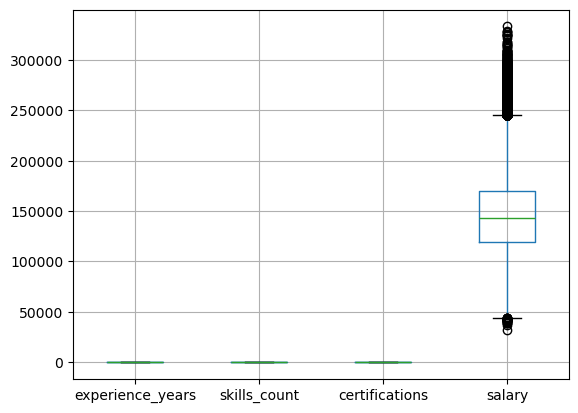

In [47]:
df.boxplot()

## EXPLORATORY DATA ANALYSIS

In [ ]:
### Does experience increase salary?
### Which job titles pay the most?
### Do more skills lead to higher pay?
### What is the correlation to industry and salary? 
### What top 5 industries have the highest salaries, and what top 5 industries have the lowest salaries?
### Are certifications important in all industries?
### How location affects salaries?

In [42]:
df[['experience_years', 'salary']].corr() 

# Correlation scale (simple version):

# 0.0 = no relationship
# 0.1 to 0.3 = weak
# 0.3 to 0.6 = moderate
# 0.6+ = strong

,experience_years,salary
experience_years,1.000000,0.437627
salary,0.437627,1.000000


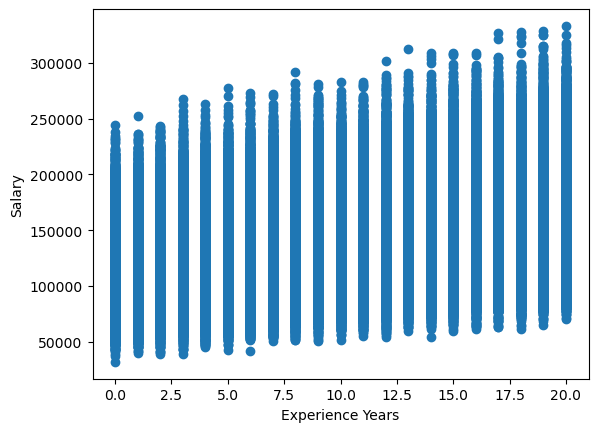

In [43]:
import matplotlib.pyplot as plt  
plt.scatter(df['experience_years'], df['salary'])
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.show()

In [44]:
df.groupby('job_title')['salary'].mean().sort_values(ascending=False)

job_title
AI Engineer                  173498.480640
Machine Learning Engineer    163022.504570
Product Manager              157594.932029
Cloud Engineer               152102.535290
DevOps Engineer              149959.266791
Cybersecurity Analyst        148697.695548
Data Scientist               147258.214409
Software Engineer            141739.521460
Backend Developer            139202.768663
Frontend Developer           132653.842485
Business Analyst             122551.231354
Data Analyst                 119891.696603
Name: salary, dtype: float64

In [45]:
df.groupby('education_level')['salary'].mean()

education_level
Bachelor       142410.531291
Diploma        137158.574976
High School    131715.336243
Master         153305.307833
PhD            163976.005295
Name: salary, dtype: float64

<Axes: xlabel='company_size', ylabel='salary'>

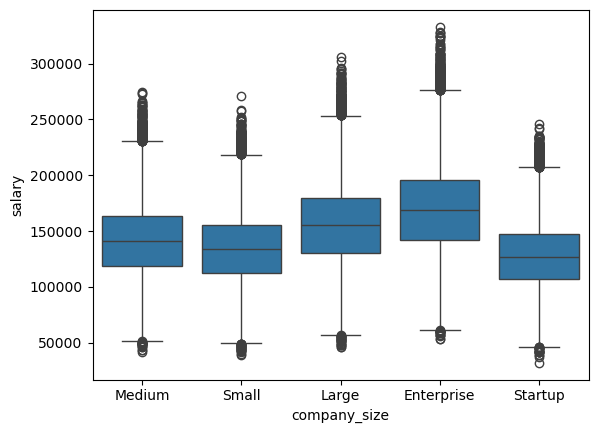

In [48]:
import seaborn as sns

sns.boxplot(x='company_size', y='salary', data=df)


<Axes: xlabel='remote_work', ylabel='salary'>

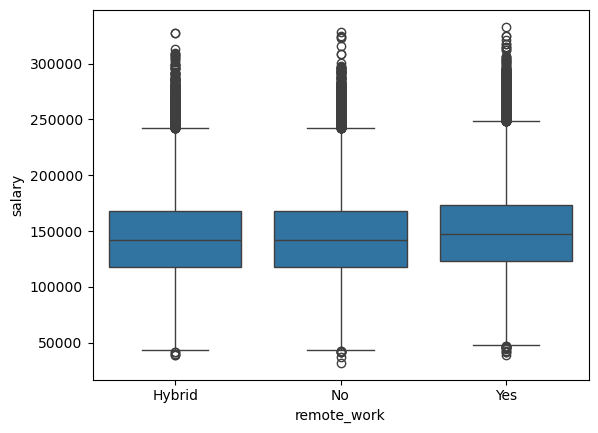

In [49]:
sns.boxplot(x='remote_work', y='salary', data=df)

<Axes: >

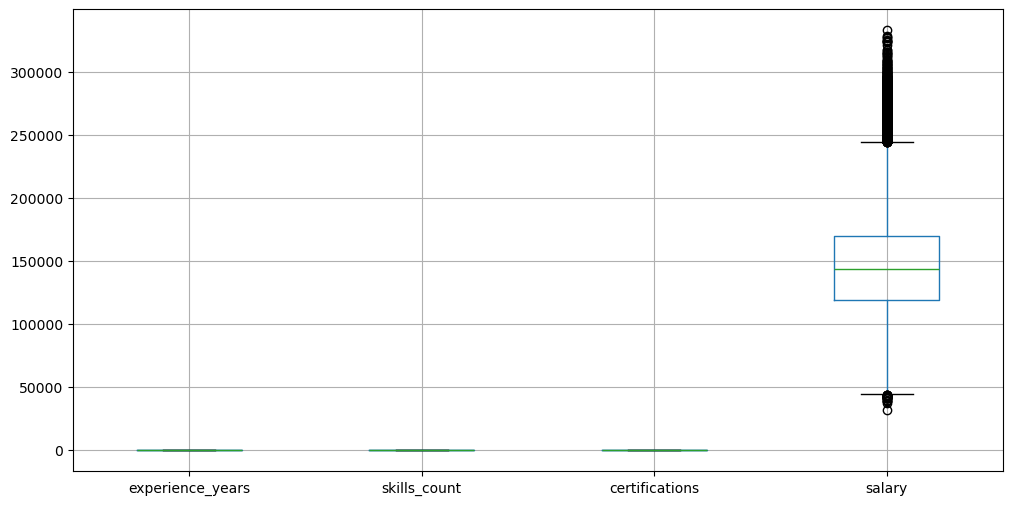

In [50]:
df.boxplot(figsize=(12,6))

In [51]:
df.groupby('industry')['salary'].mean().sort_values(ascending=False)

industry
Education        145993.564547
Media            145891.271071
Telecom          145876.511967
Technology       145863.808377
Finance          145801.639468
Healthcare       145759.995702
Government       145613.869242
Manufacturing    145530.603301
Consulting       145451.638293
Retail           145399.699408
Name: salary, dtype: float64

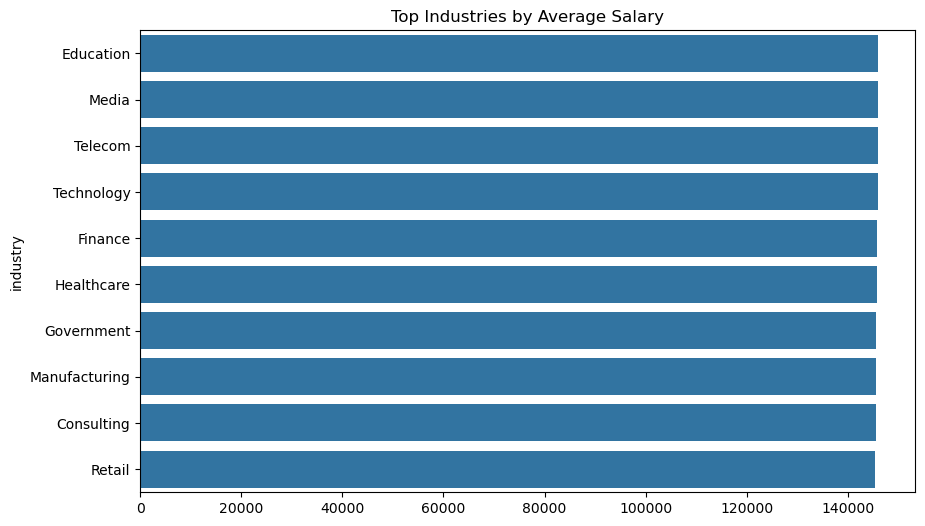

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(
    x=df.groupby('industry')['salary'].mean().sort_values(ascending=False).values[:10],
    y=df.groupby('industry')['salary'].mean().sort_values(ascending=False).index[:10]
)
plt.title("Top Industries by Average Salary")
plt.show()

In [53]:
df.groupby('industry')['salary'].mean().sort_values(ascending=False).head(5)

industry
Education     145993.564547
Media         145891.271071
Telecom       145876.511967
Technology    145863.808377
Finance       145801.639468
Name: salary, dtype: float64

In [54]:
df.groupby('industry')['salary'].mean().sort_values(ascending=True).head(5)

industry
Retail           145399.699408
Consulting       145451.638293
Manufacturing    145530.603301
Government       145613.869242
Healthcare       145759.995702
Name: salary, dtype: float64

In [56]:
df.groupby('certifications')['salary'].mean()

certifications
0    141492.411877
1    143428.188796
2    144868.706976
3    146884.292491
4    148103.275327
5    149607.379081
Name: salary, dtype: float64

<Axes: xlabel='certifications', ylabel='salary'>

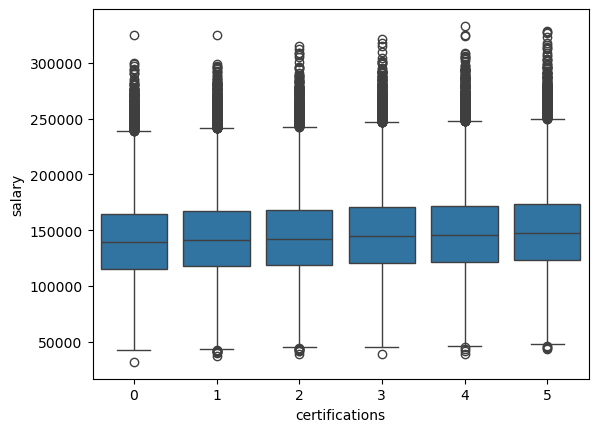

In [58]:
sns.boxplot(x='certifications', y='salary', data=df)

In [60]:
df.groupby(['industry', 'certifications'])['salary'].mean()

industry       certifications
Consulting     0                 141406.421664
               1                 142818.310017
               2                 145186.615998
               3                 145695.106499
               4                 147420.337611
               5                 150162.554099
Education      0                 141632.807947
               1                 145086.907840
               2                 144500.839375
               3                 146978.562754
               4                 147771.578151
               5                 149885.061811
Finance        0                 141151.045508
               1                 144008.682358
               2                 145347.433927
               3                 146741.834920
               4                 148030.864911
               5                 149754.416083
Government     0                 141984.976457
               1                 143177.879865
               2              

In [61]:
df.groupby('location')['salary'].mean().sort_values(ascending=False)

location
USA            181716.303919
Canada         167391.273396
UK             160075.143018
Germany        153376.211000
Remote         139442.525155
Sweden         139440.637291
Australia      139362.150804
Singapore      139340.696625
Netherlands    139294.813644
India           97690.402249
Name: salary, dtype: float64

In [62]:
df.groupby('location')['salary'].mean().sort_values(ascending=False).head(10)

location
USA            181716.303919
Canada         167391.273396
UK             160075.143018
Germany        153376.211000
Remote         139442.525155
Sweden         139440.637291
Australia      139362.150804
Singapore      139340.696625
Netherlands    139294.813644
India           97690.402249
Name: salary, dtype: float64

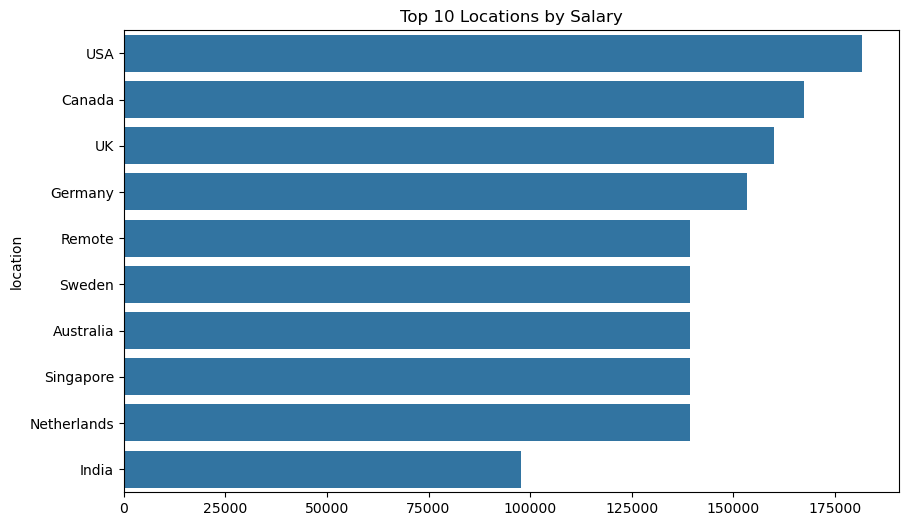

In [63]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=df.groupby('location')['salary'].mean().sort_values(ascending=False).head(10).values,
    y=df.groupby('location')['salary'].mean().sort_values(ascending=False).head(10).index
)
plt.title("Top 10 Locations by Salary")
plt.show()

### PREPROCESSING


In [65]:
X = df.drop('salary', axis=1)
y = df['salary']